# Proyecto Transversal — Gestión de Proyectos de Inteligencia de Negocio
## AdventureWorks: Análisis inicial para la dirección general

---

**Contexto del caso**  
Juana Rider es Data Analyst en un grupo multinacional que fabrica y vende bicicletas y repuestos. Antes de iniciar el proyecto de Inteligencia de Negocio, la dirección general le pide responder a cuatro preguntas estratégicas a partir del dataset `dataset_AW.xlsx`.

**Pestañas del dataset:**
- `ST Ventas Totales` — ventas diarias de ≈3 años
- `Var Discreta Adq Bicicleta` — detalle de 18 484 clientes
- `Datos sin etiquetas (No Supervisado)` — catálogo de productos

**Preguntas a responder:**
1. ¿En qué país se concentra la mayor facturación? (Top 10)
2. ¿Qué tendencia tienen las ventas de la empresa?
3. ¿Cuál es el precio medio por categoría de producto? ¿Influye el color?
4. ¿Qué características tienen los compradores de bicicletas?
5. Conclusiones finales para la dirección

---

## 0. Importación de librerías y carga del dataset

Importamos las librerías necesarias para el análisis:
- **pandas**: manipulación y análisis de datos tabulares.
- **matplotlib / seaborn**: visualización estática de gráficos.
- **numpy**: operaciones numéricas de apoyo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente para todos los gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


In [4]:
# Cargamos las tres pestañas del dataset en dataframes independientes
# sheet_name=None devuelve un diccionario con todas las hojas
RUTA = 'dataset_AW.xlsx'

df_clientes = pd.read_excel(RUTA, sheet_name='Var Discreta Adq Bicicleta')
df_ventas   = pd.read_excel(RUTA, sheet_name='ST Ventas Totales ')
df_prod     = pd.read_excel(RUTA, sheet_name='Datos sin etiquetas (No Supervs')

print(f'df_clientes : {df_clientes.shape[0]:,} filas × {df_clientes.shape[1]} columnas')
print(f'df_ventas   : {df_ventas.shape[0]:,} filas × {df_ventas.shape[1]} columnas')
print(f'df_prod     : {df_prod.shape[0]:,} filas × {df_prod.shape[1]} columnas')

df_clientes : 18,484 filas × 19 columnas
df_ventas   : 1,124 filas × 2 columnas
df_prod     : 121,317 filas × 13 columnas


### Inspección rápida de cada tabla

Antes de responder a las preguntas de negocio, revisamos la calidad de los datos: tipos de columna, valores nulos y estadísticos básicos. Este paso es obligatorio en cualquier proyecto de BI siguiendo el flujo **Descubrimiento → Análisis → Recomendaciones** (Tema 2).

In [5]:
print('=== df_clientes — primeras filas ===')
display(df_clientes.head(3))

print('\n--- Tipos de dato y nulos ---')
df_clientes.info()

print('\n--- Nulos por columna ---')
print(df_clientes.isnull().sum()[df_clientes.isnull().sum() > 0])

=== df_clientes — primeras filas ===


,TotalAmount,BikePurchase,CustomerID,Country,CountryRegionCode,Group,PersonID,PersonType,DateFirstPurchase,BirthDate,Age,MaritalStatus,YearlyIncome,Gender,TotalChildren,Education,Occupation,HomeOwnerFlag,NumberCarsOwned
0,8139.2900,1,11003,Australia,AU,Pacific,11358,IN,2001-07-01,1968-02-15,52,S,50001-75000,F,0,Bachelors,Professional,0,1
1,2994.0882,1,14501,Southwest,US,North America,11211,IN,2001-07-01,1938-05-13,82,M,75001-100000,M,4,Graduate Degree,Management,1,2
2,4118.2600,1,21768,Canada,CA,North America,14078,IN,2001-07-01,1946-08-22,74,S,50001-75000,M,5,Bachelors,Management,1,3



--- Tipos de dato y nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18484 entries, 0 to 18483
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TotalAmount        18484 non-null  float64       
 1   BikePurchase       18484 non-null  int64         
 2   CustomerID         18484 non-null  int64         
 3   Country            18484 non-null  object        
 4   CountryRegionCode  18484 non-null  object        
 5   Group              18484 non-null  object        
 6   PersonID           18484 non-null  int64         
 7   PersonType         18484 non-null  object        
 8   DateFirstPurchase  18484 non-null  datetime64[ns]
 9   BirthDate          18484 non-null  datetime64[ns]
 10  Age                18484 non-null  int64         
 11  MaritalStatus      18484 non-null  object        
 12  YearlyIncome       18484 non-null  object        
 13  Gender             18484 non-n

In [6]:
print('=== df_ventas — primeras filas ===')
display(df_ventas.head(3))
print(f"\nRango temporal: {df_ventas['OrderDate'].min().date()} → {df_ventas['OrderDate'].max().date()}")
print(f"Nulos: {df_ventas.isnull().sum().sum()}")

=== df_ventas — primeras filas ===


,OrderDate,Sales
0,2011-05-31,503805.9169
1,2011-06-01,13931.5200
2,2011-06-02,15012.1782



Rango temporal: 2011-05-31 → 2014-06-30
Nulos: 0


In [7]:
print('=== df_prod — primeras filas ===')
display(df_prod.head(3))
print(f"\nCategorías de producto únicas: {df_prod['Name'].nunique()}")
print(df_prod['Name'].value_counts().head(5))

=== df_prod — primeras filas ===


,SalesOrderID,OrderQty,UnitPrice,ProductID,Color,SafetyStockLevel,ReorderPoint,StandardCost,ListPrice,Size,Weight,DaysToManufacture,Name
0,43659,1,2024.994,776,Black,100,75,1898.0944,3374.99,42,20.77,4,Mountain Bikes
1,43659,3,2024.994,777,Black,100,75,1898.0944,3374.99,44,21.13,4,Mountain Bikes
2,43659,1,2024.994,778,Black,100,75,1898.0944,3374.99,48,21.42,4,Mountain Bikes



Categorías de producto únicas: 35
Name
Road Bikes           20944
Tires and Tubes      17495
Mountain Bikes       12457
Helmets               9180
Bottles and Cages     8425
Name: count, dtype: int64


---
## Criterio 1 — ¿En qué país se concentra la mayor facturación?

**Fuente de datos:** pestaña `Var Discreta Adq Bicicleta`, variables `Country` y `TotalAmount`.  
**Objetivo:** identificar los 10 mercados que más facturan para priorizar recursos comerciales.

**Decisiones metodológicas:**
- Usamos `groupby` + `sum` para agregar la facturación total por país.
- Ordenamos de mayor a menor y tomamos el Top 10.
- El gráfico de barras horizontales facilita la lectura de etiquetas largas.

In [8]:
# ── Agregación: facturación total por país ─────────────────────────────────
facturacion_pais = (
    df_clientes
    .groupby('Country')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
facturacion_pais.columns = ['País', 'Facturación Total (USD)']

# Calculamos el porcentaje sobre el total para enriquecer el análisis
total_global = df_clientes['TotalAmount'].sum()
facturacion_pais['% sobre total'] = (
    facturacion_pais['Facturación Total (USD)'] / total_global * 100
).round(2)

print('Top 10 países por facturación:')
display(facturacion_pais.style.format({'Facturación Total (USD)': '{:,.2f}', '% sobre total': '{:.2f}%'}))

Top 10 países por facturación:


,País,Facturación Total (USD),% sobre total
0,Australia,"9,061,000.58",30.86%
1,Southwest,"5,718,150.81",19.48%
2,Northwest,"3,649,866.55",12.43%
3,United Kingdom,"3,391,712.21",11.55%
4,Germany,"2,894,312.34",9.86%
5,France,"2,644,017.71",9.01%
6,Canada,"1,977,844.86",6.74%
7,Southeast,"12,238.85",0.04%
8,Northeast,"6,532.47",0.02%
9,Central,"3,000.83",0.01%


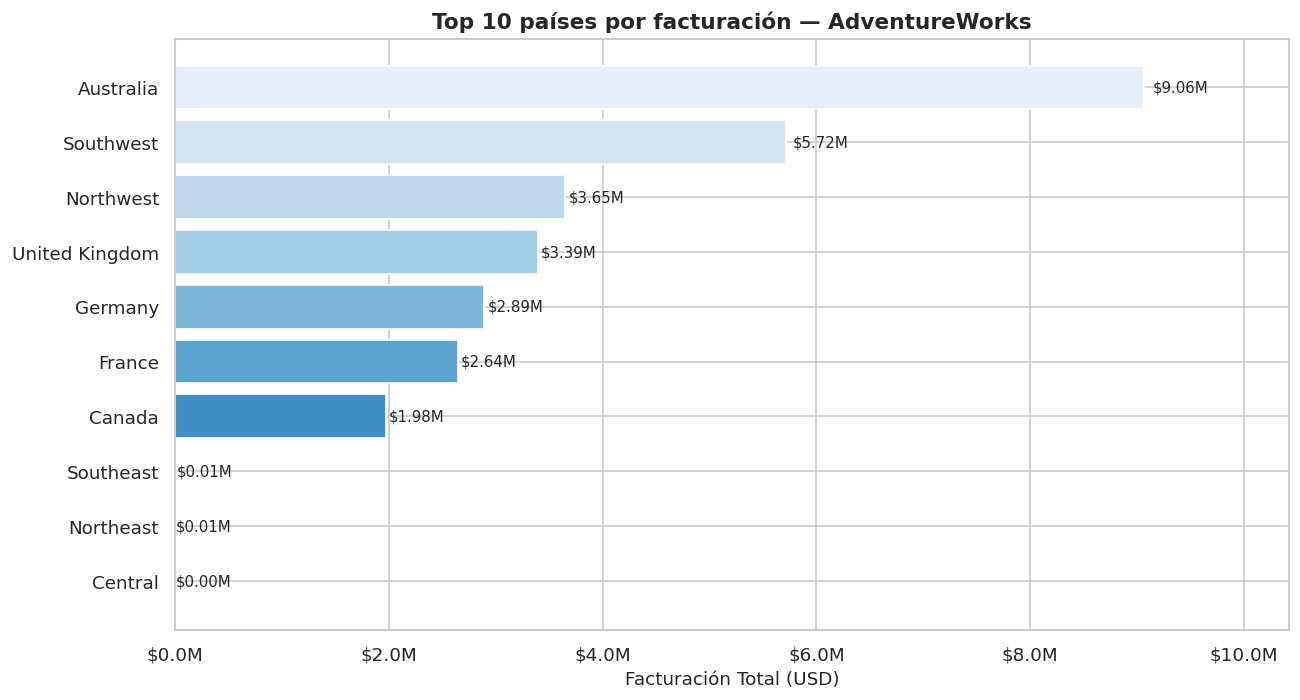

In [9]:
# ── Gráfico: Top 10 países por facturación ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

# Barras horizontales ordenadas de mayor a menor (invertimos para que el 1º quede arriba)
bars = ax.barh(
    facturacion_pais['País'][::-1],
    facturacion_pais['Facturación Total (USD)'][::-1],
    color=sns.color_palette('Blues_r', n_colors=10)
)

# Etiquetas de valor al final de cada barra
for bar, val in zip(bars, facturacion_pais['Facturación Total (USD)'][::-1]):
    ax.text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f'${val/1e6:.2f}M',
        va='center', fontsize=9
    )

ax.set_xlabel('Facturación Total (USD)', fontsize=11)
ax.set_title('Top 10 países por facturación — AdventureWorks', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlim(0, facturacion_pais['Facturación Total (USD)'].max() * 1.15)
plt.tight_layout()
plt.show()

###Hallazgos — Criterio 1

| Posición | País / Región | Facturación aprox. | % del total |
|---|---|---|---|
| 1 | **Australia** | 9,06 M USD | ~30 % |
| 2 | Southwest (EE. UU.) | 5,72 M USD | ~19 % |
| 3 | Northwest (EE. UU.) | 3,65 M USD | ~12 % |
| 4 | United Kingdom | 3,39 M USD | ~11 % |
| 5 | Germany | 2,89 M USD | ~10 % |

**Conclusiones clave:**
- **Australia es, con diferencia, el mercado más rentable**, concentrando casi un tercio de la facturación total a pesar de no ser el país con más clientes (3 591 frente a los 4 450 de Southwest). Esto indica un **ticket medio muy superior** en Australia.
- Los mercados de **EE. UU. combinados** (Southwest + Northwest + Southeast + Northeast + Central) superan a Australia, lo que sugiere que el mercado estadounidense es el más voluminoso en conjunto.
- Los mercados de **Southeast, Northeast y Central** tienen una facturación testimonial (< 15 000 USD), lo que puede señalar mercados emergentes o zonas de distribución limitada que merecen revisión estratégica.
- **Implicación de negocio:** la estrategia comercial debería priorizar la fidelización en Australia y Southwest, y estudiar el bajo rendimiento de las regiones menores de EE. UU.

---
## Criterio 2 — Tendencia de ventas de la empresa

**Fuente de datos:** pestaña `ST Ventas Totales`, variables `OrderDate` y `Sales`.  
**Objetivo:** representar la evolución temporal de las ventas e identificar la tendencia de crecimiento.

**Decisiones metodológicas:**
- Agrupamos las ventas diarias por **mes** para suavizar el ruido y obtener una curva legible.
- Añadimos una **media móvil de 3 meses** para visualizar la tendencia subyacente sin la volatilidad puntual.
- La serie abarca **mayo 2011 – junio 2014** (≈ 3 años).

In [10]:
# ── Agregación mensual de ventas ───────────────────────────────────────────
df_ventas['Mes'] = df_ventas['OrderDate'].dt.to_period('M')
ventas_mes = (
    df_ventas
    .groupby('Mes')['Sales']
    .sum()
    .reset_index()
)
ventas_mes['Mes_dt'] = ventas_mes['Mes'].dt.to_timestamp()

# Media móvil de 3 meses para visualizar la tendencia
ventas_mes['MM3'] = ventas_mes['Sales'].rolling(window=3, min_periods=1).mean()

# Resumen por año para contexto
df_ventas['Year'] = df_ventas['OrderDate'].dt.year
resumen_anual = df_ventas.groupby('Year')['Sales'].sum()
print('Ventas totales por año (USD):')
for yr, val in resumen_anual.items():
    print(f'  {yr}: ${val:,.0f}')

print(f'\nCrecimiento 2011 → 2013: +{((resumen_anual[2013]/resumen_anual[2011])-1)*100:.1f}%')

Ventas totales por año (USD):
  2011: $12,641,672
  2012: $33,524,301
  2013: $43,622,479
  2014: $20,057,929

Crecimiento 2011 → 2013: +245.1%


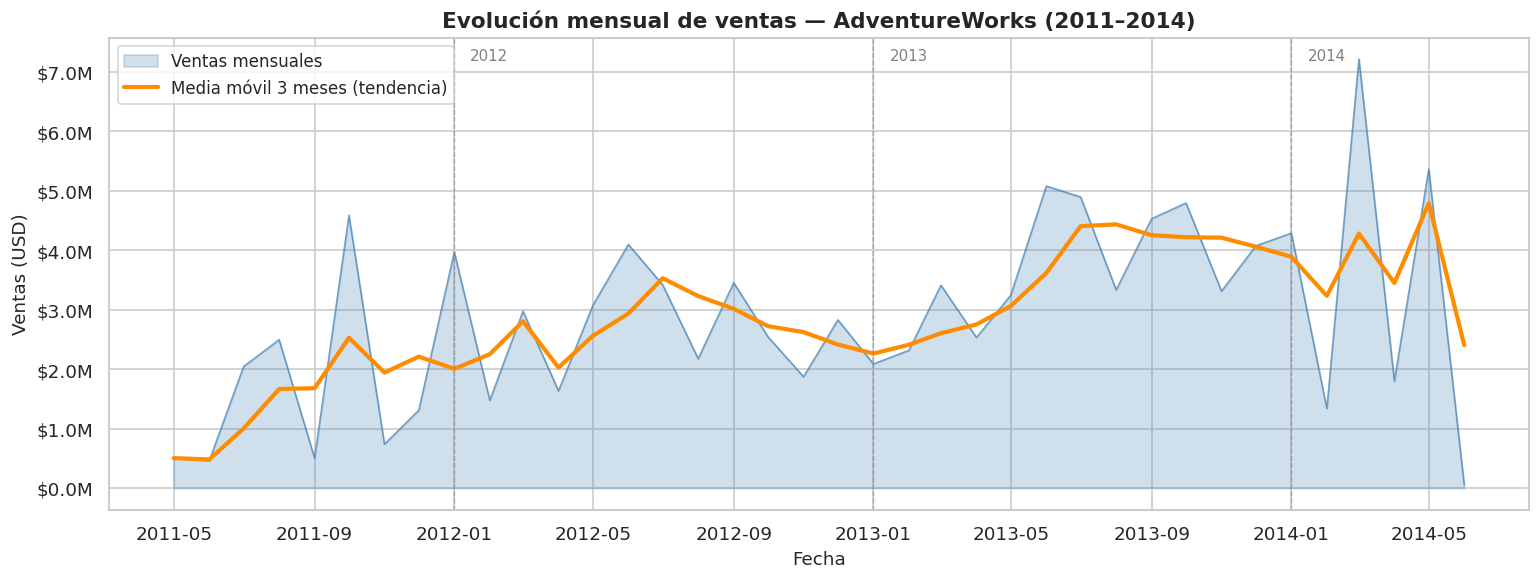

In [11]:
# ── Gráfico: serie temporal de ventas mensuales ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Ventas mensuales como área
ax.fill_between(ventas_mes['Mes_dt'], ventas_mes['Sales'],
                alpha=0.25, color='steelblue', label='Ventas mensuales')
ax.plot(ventas_mes['Mes_dt'], ventas_mes['Sales'],
        color='steelblue', linewidth=1, alpha=0.7)

# Media móvil (tendencia)
ax.plot(ventas_mes['Mes_dt'], ventas_mes['MM3'],
        color='darkorange', linewidth=2.5, label='Media móvil 3 meses (tendencia)')

# Líneas verticales de separación de año
for yr in [2012, 2013, 2014]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.Timestamp(f'{yr}-01-15'), ax.get_ylim()[1] * 0.95, str(yr),
            fontsize=9, color='gray')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Ventas (USD)', fontsize=11)
ax.set_title('Evolución mensual de ventas — AdventureWorks (2011–2014)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

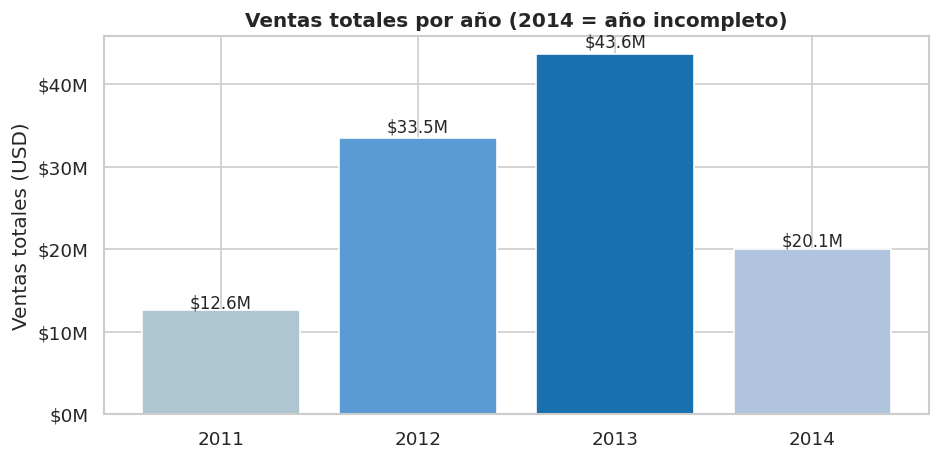

In [12]:
# ── Gráfico complementario: ventas anuales comparadas ─────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colores = ['#aec6cf', '#5b9bd5', '#1a6faf', '#b0c4de']  # 2014 más claro (año incompleto)
bars = ax.bar(resumen_anual.index.astype(str), resumen_anual.values, color=colores, edgecolor='white')

for bar, val in zip(bars, resumen_anual.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f'${val/1e6:.1f}M', ha='center', fontsize=10)

ax.set_ylabel('Ventas totales (USD)')
ax.set_title('Ventas totales por año (2014 = año incompleto)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

### Hallazgos — Criterio 2

| Año | Ventas totales | Variación |
|---|---|---|
| 2011 (parcial) | ≈ 12,6 M USD | — |
| 2012 | ≈ 33,5 M USD | +166 % |
| 2013 | ≈ 43,6 M USD | +30 % |
| 2014 (parcial) | ≈ 20,1 M USD | — |

**La tendencia de ventas de AdventureWorks es claramente alcista:**
- Las ventas crecen de forma sostenida desde 2011 hasta 2013. El salto más pronunciado se produce entre 2011 y 2012 (+166 %).
- La media móvil de 3 meses confirma la **tendencia creciente** sin picos puntuales que distorsionen la lectura.
- Se aprecian **picos estacionales** recurrentes (primavera-verano), coherentes con un negocio de bicicletas cuya demanda es mayor en época de buen tiempo.
- Los datos de 2014 son parciales (hasta junio), por lo que la caída aparente al final de la serie no indica deterioro del negocio.
- **Implicación de negocio:** el crecimiento sostenido justifica la inversión en un proyecto de BI. Anticipar los picos estacionales con stock y campañas de marketing puede maximizar el rendimiento.

---
## Criterio 3 — Precio medio por categoría y por color

**Fuente de datos:** pestaña `Datos sin etiquetas (No Supervisado)`, variables `Name`, `UnitPrice` y `Color`.  
**Objetivo:** conocer la política de precios actual por categoría y analizar si el color del producto influye en el precio.

**Decisiones metodológicas:**
- Usamos `UnitPrice` (precio de venta real de cada línea de pedido) en lugar de `ListPrice` para reflejar el precio efectivo pagado.
- Para el gráfico por categoría, ordenamos de mayor a menor precio para una lectura ejecutiva intuitiva.
- Para el análisis por color, complementamos con un boxplot que muestra la distribución completa, no solo la media.

In [13]:
# ── Precio medio por categoría de producto ────────────────────────────────
precio_cat = (
    df_prod
    .groupby('Name')['UnitPrice']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
precio_cat.columns = ['Categoría', 'Precio Medio (USD)']
precio_cat['Precio Medio (USD)'] = precio_cat['Precio Medio (USD)'].round(2)

print('Precio medio por categoría (USD):')
display(precio_cat.style.format({'Precio Medio (USD)': '${:,.2f}'}))

Precio medio por categoría (USD):


,Categoría,Precio Medio (USD)
0,Mountain Bikes,"$1,451.21"
1,Road Bikes,"$1,172.10"
2,Touring Bikes,"$1,146.20"
3,Mountain Frames,$432.33
4,Touring Frames,$425.50
5,Road Frames,$335.01
6,Cranksets,$179.76
7,Bike Stands,$159.00
8,Wheels,$127.61
9,Forks,$117.43


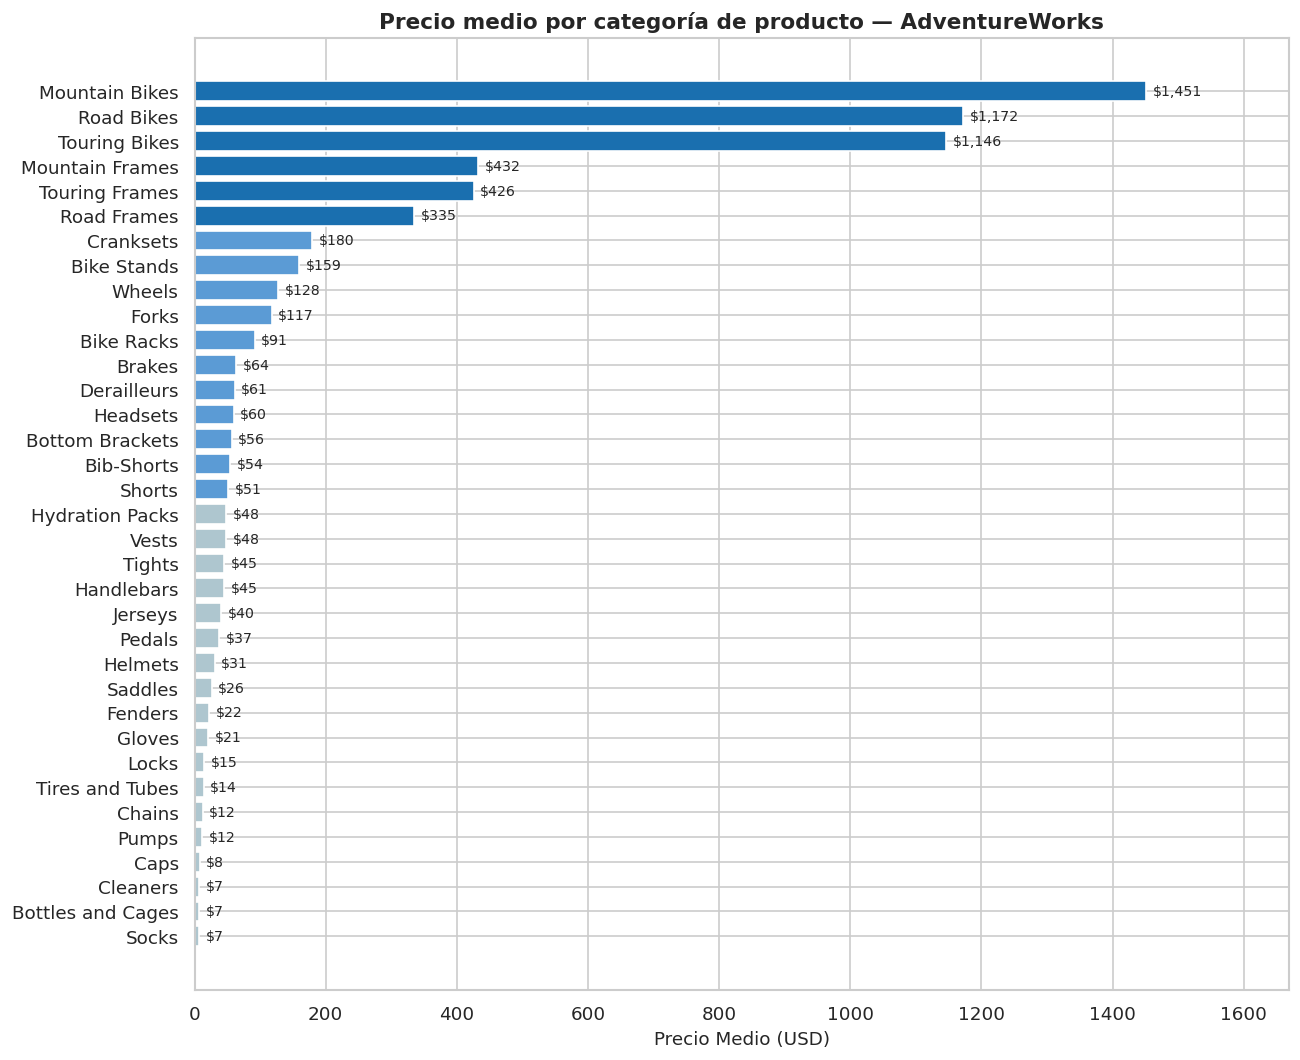

In [14]:
# ── Gráfico: precio medio por categoría ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

palette = ['#1a6faf' if p > 200 else '#5b9bd5' if p > 50 else '#aec6cf'
           for p in precio_cat['Precio Medio (USD)']]

bars = ax.barh(precio_cat['Categoría'][::-1],
               precio_cat['Precio Medio (USD)'][::-1],
               color=palette[::-1], edgecolor='white')

for bar, val in zip(bars, precio_cat['Precio Medio (USD)'][::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=8.5)

ax.set_xlabel('Precio Medio (USD)', fontsize=11)
ax.set_title('Precio medio por categoría de producto — AdventureWorks', fontsize=13, fontweight='bold')
ax.set_xlim(0, precio_cat['Precio Medio (USD)'].max() * 1.15)
plt.tight_layout()
plt.show()

In [15]:
# ── Precio medio por color del producto ───────────────────────────────────
precio_color = (
    df_prod
    .groupby('Color')['UnitPrice']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
    .reset_index()
)
precio_color.columns = ['Color', 'Precio Medio (USD)', 'Precio Mediana (USD)', 'N registros']
precio_color[['Precio Medio (USD)', 'Precio Mediana (USD)']] = \
    precio_color[['Precio Medio (USD)', 'Precio Mediana (USD)']].round(2)

print('Precio medio y mediana por color:')
display(precio_color.style.format({'Precio Medio (USD)': '${:,.2f}', 'Precio Mediana (USD)': '${:,.2f}'}))

Precio medio y mediana por color:


,Color,Precio Medio (USD),Precio Mediana (USD),N registros
0,Red,$989.94,$469.79,13065
1,Silver,$936.10,$744.27,10654
2,Yellow,$731.52,$600.26,12862
3,Black,$609.59,$323.99,30099
4,Blue,$534.43,$63.50,9044
5,Silver/Black,$37.35,$37.25,1517
6,Multi,$27.09,$28.84,8502
7,White,$6.85,$5.70,1429


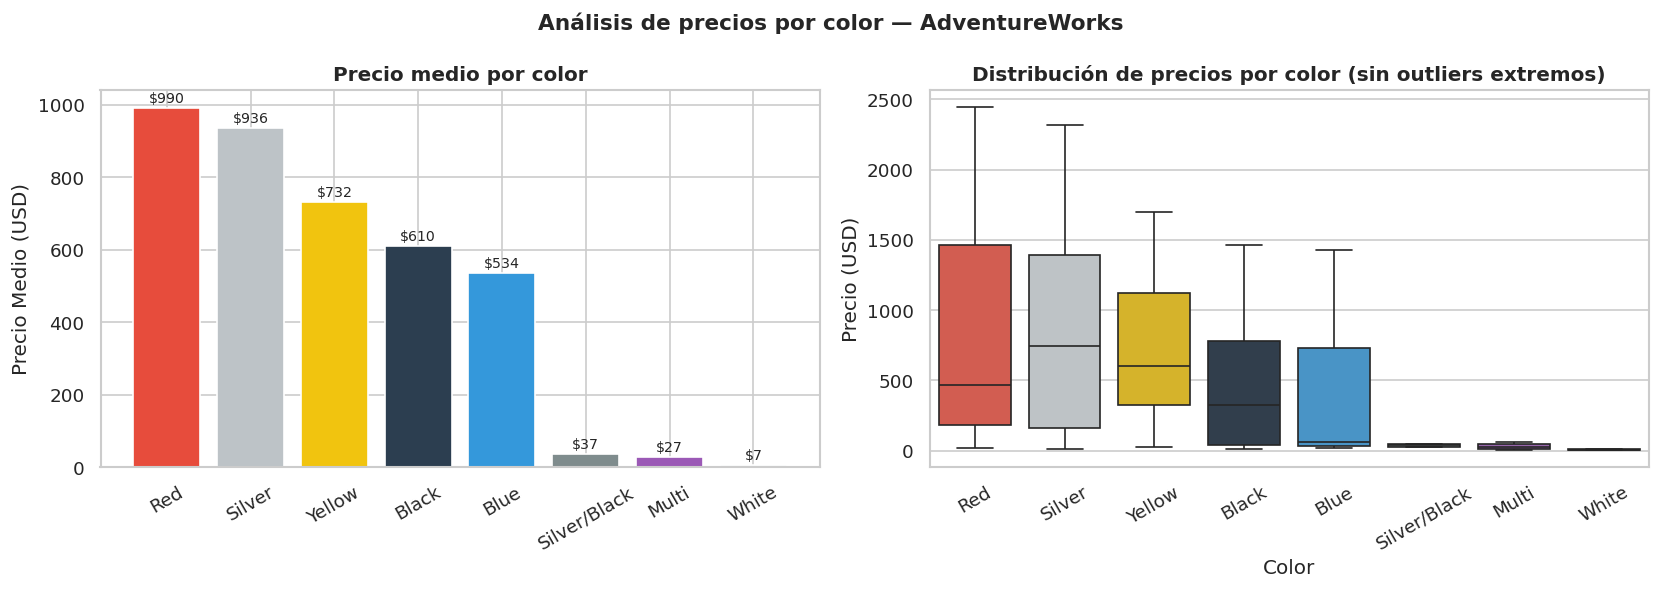

In [16]:
# ── Gráfico: precio por color (media + boxplot) ───────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: barras de precio medio
colores_barra = ['#E74C3C','#BDC3C7','#F1C40F','#2C3E50','#3498DB','#7F8C8D','#9B59B6','#ECF0F1']
ax1.bar(precio_color['Color'], precio_color['Precio Medio (USD)'],
        color=colores_barra[:len(precio_color)], edgecolor='white')
for i, (col, val) in enumerate(zip(precio_color['Color'], precio_color['Precio Medio (USD)'])):
    ax1.text(i, val + 15, f'${val:,.0f}', ha='center', fontsize=8.5)
ax1.set_ylabel('Precio Medio (USD)')
ax1.set_title('Precio medio por color', fontweight='bold')
ax1.tick_params(axis='x', rotation=30)

# Derecha: boxplot — distribución completa de precios por color
orden_color = precio_color['Color'].tolist()
sns.boxplot(data=df_prod, x='Color', y='UnitPrice', order=orden_color,
            palette=colores_barra[:len(orden_color)], ax=ax2,
            showfliers=False)  # ocultamos outliers extremos para legibilidad
ax2.set_ylabel('Precio (USD)')
ax2.set_title('Distribución de precios por color (sin outliers extremos)', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

plt.suptitle('Análisis de precios por color — AdventureWorks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Hallazgos — Criterio 3

**Por categoría de producto:**
- La categoría más cara es **Mountain Bikes** (≈ 1 451 USD de media), seguida de **Road Bikes** (≈ 1 172 USD) y **Touring Bikes** (≈ 1 146 USD). Las bicicletas completas concentran el mayor valor unitario.
- Los **cuadros** (Frames) son la segunda gran familia de precio elevado (300–430 USD), seguidos de componentes como Cranksets o Wheels.
- Los **accesorios** (ropa, guantes, botellas, calcetines) tienen precios muy bajos (< 55 USD), pero pueden representar un volumen de unidades alto.
- **Implicación:** la estrategia de margen debería diferenciarse entre el segmento premium (bicicletas completas) y el segmento de accesorios, donde el volumen compensa el bajo ticket.

**Por color del producto:**
- Los productos **rojos** tienen el precio medio más alto (≈ 990 USD), seguidos de los **plateados** (≈ 936 USD) y **amarillos** (≈ 732 USD). Esto se debe a que estos colores están asociados con las gamas altas de bicicletas.
- Los productos **blancos** tienen el precio más bajo (≈ 7 USD), lo que corresponde a accesorios de bajo coste (calcetines).
- **Sí existe diferencia de precios por color**, aunque la causa es la categoría de producto asociada a ese color, no el color en sí mismo. El boxplot confirma que la varianza dentro de cada color es alta, reflejando que un mismo color cubre múltiples categorías.

---
## Criterio 4 — Perfil de los compradores de bicicletas

**Fuente de datos:** pestaña `Var Discreta Adq Bicicleta`, variable `BikePurchase` (1 = comprador) y el resto de variables del cliente.  
**Objetivo:** construir el perfil sociodemográfico y económico del comprador de bicicletas para segmentar campañas de marketing.

**Decisiones metodológicas:**
- Separamos el dataset en dos grupos: **compradores** (`BikePurchase == 1`) y **no compradores** (`BikePurchase == 0`).
- Analizamos 7 dimensiones clave: género, edad, educación, ocupación, ingresos, estado civil y propiedad de vivienda.
- Usamos porcentajes (no conteos absolutos) para que los grupos sean comparables aunque tengan tamaños distintos.

In [17]:
# ── Separación de grupos ────────────────────────────────────────────────────
compradores  = df_clientes[df_clientes['BikePurchase'] == 1].copy()
no_compradores = df_clientes[df_clientes['BikePurchase'] == 0].copy()

n_comp   = len(compradores)
n_nocomp = len(no_compradores)
print(f'Compradores de bicicleta (BikePurchase=1) : {n_comp:,} ({n_comp/len(df_clientes)*100:.1f}%)')
print(f'No compradores         (BikePurchase=0) : {n_nocomp:,} ({n_nocomp/len(df_clientes)*100:.1f}%)')
print(f'Gasto medio COMPRADORES   : ${compradores["TotalAmount"].mean():,.2f}')
print(f'Gasto medio NO compradores: ${no_compradores["TotalAmount"].mean():,.2f}')

Compradores de bicicleta (BikePurchase=1) : 9,132 (49.4%)
No compradores         (BikePurchase=0) : 9,352 (50.6%)
Gasto medio COMPRADORES   : $3,145.66
Gasto medio NO compradores: $67.63


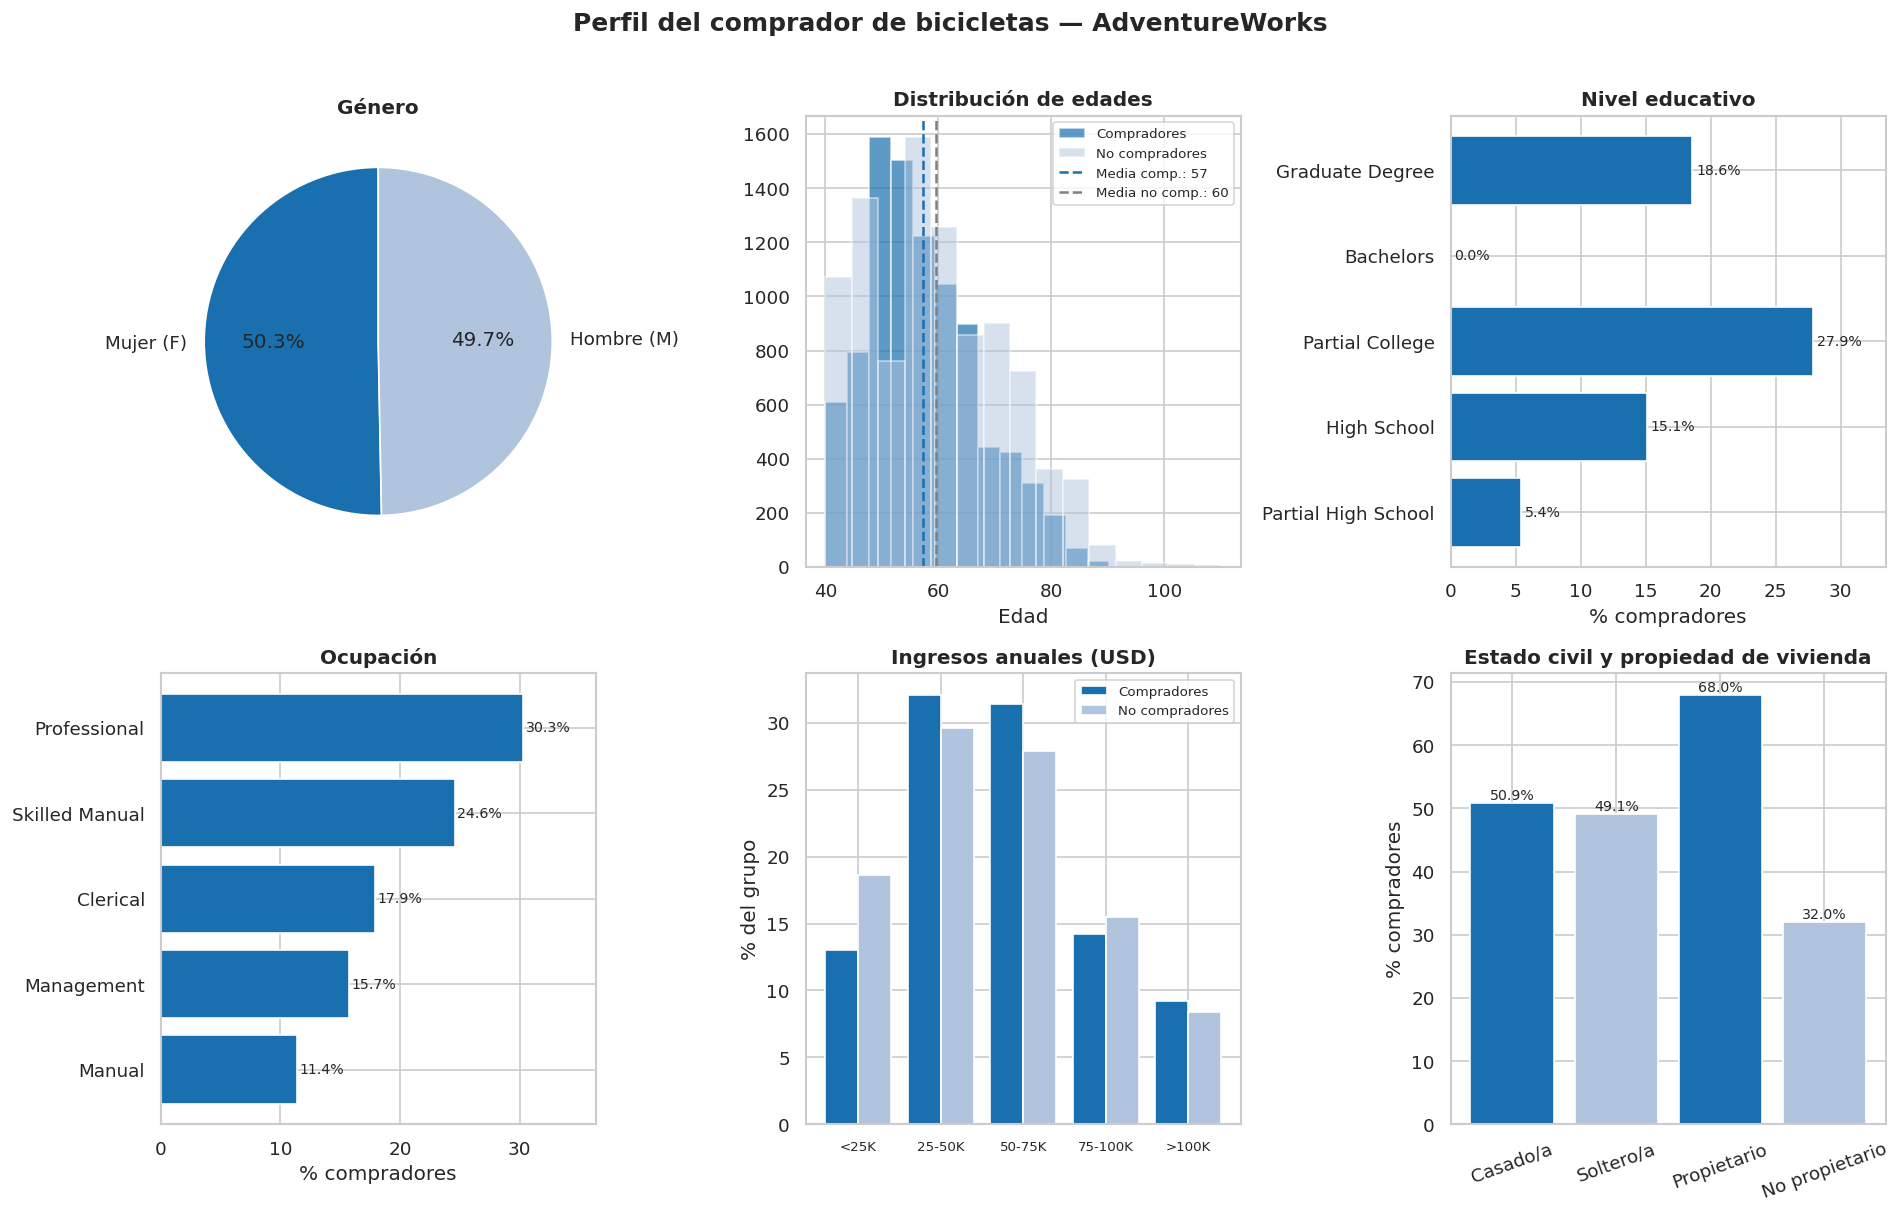

In [18]:
# ── Dashboard de perfil: 6 subgráficos ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Perfil del comprador de bicicletas — AdventureWorks', fontsize=15, fontweight='bold', y=1.01)

AZUL = '#1a6faf'
GRIS = '#b0c4de'

def pct(grupo, col):
    """Devuelve porcentajes de una variable categórica en un grupo."""
    return grupo[col].value_counts(normalize=True).mul(100).round(1)

# ── 1. Género ────────────────────────────────────────────────────────────
gen = pct(compradores, 'Gender')
gen.index = ['Mujer (F)' if x == 'F' else 'Hombre (M)' for x in gen.index]
axes[0, 0].pie(gen.values, labels=gen.index, autopct='%1.1f%%',
               colors=[AZUL, GRIS], startangle=90)
axes[0, 0].set_title('Género', fontweight='bold')

# ── 2. Edad (histograma comparativo) ─────────────────────────────────────
axes[0, 1].hist(compradores['Age'], bins=15, alpha=0.7, color=AZUL, label='Compradores')
axes[0, 1].hist(no_compradores['Age'], bins=15, alpha=0.5, color=GRIS, label='No compradores')
axes[0, 1].axvline(compradores['Age'].mean(), color=AZUL, linestyle='--',
                   linewidth=1.5, label=f'Media comp.: {compradores["Age"].mean():.0f}')
axes[0, 1].axvline(no_compradores['Age'].mean(), color='gray', linestyle='--',
                   linewidth=1.5, label=f'Media no comp.: {no_compradores["Age"].mean():.0f}')
axes[0, 1].set_xlabel('Edad')
axes[0, 1].set_title('Distribución de edades', fontweight='bold')
axes[0, 1].legend(fontsize=8)

# ── 3. Nivel educativo ───────────────────────────────────────────────────
edu_orden = ['Partial High School', 'High School', 'Partial College', 'Bachelors', 'Graduate Degree']
edu = pct(compradores, 'Education').reindex(edu_orden, fill_value=0)
axes[0, 2].barh(edu.index, edu.values, color=AZUL, edgecolor='white')
for i, v in enumerate(edu.values):
    axes[0, 2].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8.5)
axes[0, 2].set_xlabel('% compradores')
axes[0, 2].set_title('Nivel educativo', fontweight='bold')
axes[0, 2].set_xlim(0, edu.max() * 1.2)

# ── 4. Ocupación ─────────────────────────────────────────────────────────
ocu = pct(compradores, 'Occupation').sort_values()
axes[1, 0].barh(ocu.index, ocu.values, color=AZUL, edgecolor='white')
for i, v in enumerate(ocu.values):
    axes[1, 0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8.5)
axes[1, 0].set_xlabel('% compradores')
axes[1, 0].set_title('Ocupación', fontweight='bold')
axes[1, 0].set_xlim(0, ocu.max() * 1.2)

# ── 5. Ingresos anuales ──────────────────────────────────────────────────
ingresos_orden = ['0-25000', '25001-50000', '50001-75000', '75001-100000', 'greater than 100000']
ing_comp   = pct(compradores, 'YearlyIncome').reindex(ingresos_orden, fill_value=0)
ing_nocomp = pct(no_compradores, 'YearlyIncome').reindex(ingresos_orden, fill_value=0)

x = range(len(ingresos_orden))
axes[1, 1].bar([i - 0.2 for i in x], ing_comp.values, width=0.4, label='Compradores', color=AZUL)
axes[1, 1].bar([i + 0.2 for i in x], ing_nocomp.values, width=0.4, label='No compradores', color=GRIS)
axes[1, 1].set_xticks(list(x))
axes[1, 1].set_xticklabels(['<25K', '25-50K', '50-75K', '75-100K', '>100K'], fontsize=8)
axes[1, 1].set_ylabel('% del grupo')
axes[1, 1].set_title('Ingresos anuales (USD)', fontweight='bold')
axes[1, 1].legend(fontsize=8)

# ── 6. Estado civil y propiedad de vivienda ──────────────────────────────
mc = pct(compradores, 'MaritalStatus')
mc.index = ['Casado/a' if x == 'M' else 'Soltero/a' for x in mc.index]
hown = pct(compradores, 'HomeOwnerFlag')
hown.index = ['Propietario' if x == 1 else 'No propietario' for x in hown.index]

combined = pd.concat([mc, hown])
colors_c = [AZUL, GRIS, AZUL, GRIS]
axes[1, 2].bar(combined.index, combined.values, color=colors_c, edgecolor='white')
for i, v in enumerate(combined.values):
    axes[1, 2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8.5)
axes[1, 2].set_ylabel('% compradores')
axes[1, 2].set_title('Estado civil y propiedad de vivienda', fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

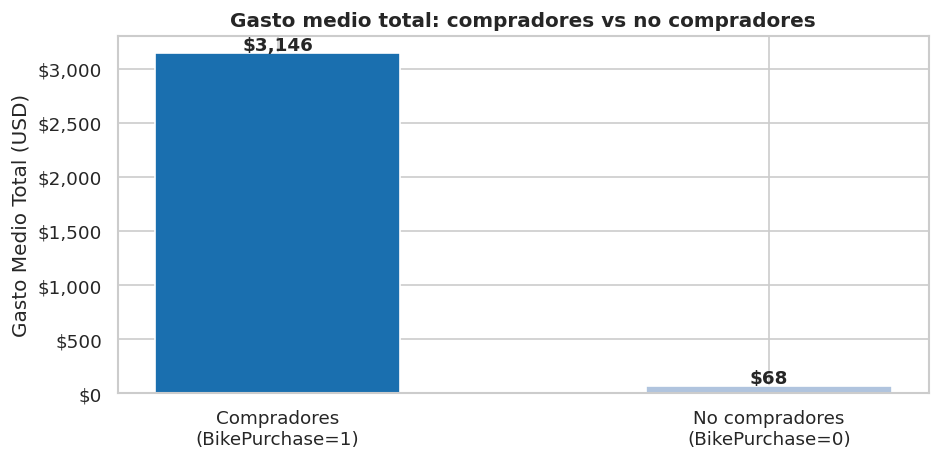


Un comprador de bicicleta gasta en media 46.5x más que un no comprador.


In [19]:
# ── Gasto total: compradores vs no compradores ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

medias = {
    'Compradores\n(BikePurchase=1)':     compradores['TotalAmount'].mean(),
    'No compradores\n(BikePurchase=0)': no_compradores['TotalAmount'].mean()
}

bars = ax.bar(medias.keys(), medias.values(), color=[AZUL, GRIS], edgecolor='white', width=0.5)
for bar, val in zip(bars, medias.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Gasto Medio Total (USD)')
ax.set_title('Gasto medio total: compradores vs no compradores', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

ratio = compradores['TotalAmount'].mean() / no_compradores['TotalAmount'].mean()
print(f'\nUn comprador de bicicleta gasta en media {ratio:.1f}x más que un no comprador.')

### Hallazgos — Criterio 4: Perfil del comprador de bicicletas

| Dimensión | Perfil del comprador |
|---|---|
| **Género** | Prácticamente paritario (F: 50,3% / M: 49,7%) |
| **Edad media** | 57 años (ligeramente menor que los no compradores, 59 años) |
| **Educación** | Mayoritariamente con estudios universitarios: Bachelor's (33%) + Partial College (28%) + Graduate (19%) |
| **Ocupación** | Professional (30%) y Skilled Manual (25%) son los perfiles dominantes |
| **Ingresos** | Franja media: 25 001–75 000 USD/año concentra el 63% de los compradores |
| **Estado civil** | Casados (51%) y solteros (49%): sin diferencia significativa |
| **Vivienda** | 68% son propietarios de su vivienda |
| **Gasto total** | **46x mayor** que los no compradores (3 146 USD vs 68 USD) |

**Perfil síntesis del comprador de bicicletas de AdventureWorks:**  
Persona de **55–60 años**, **con formación universitaria**, **profesional o técnico cualificado**, con **ingresos medios de 25 000–75 000 USD/año** y **propietario de su vivienda**. El género no es un factor diferenciador. El dato más relevante es la **enorme diferencia de gasto** entre compradores y no compradores: un cliente que adquiere una bicicleta gasta 46 veces más en total, lo que confirma que retener a este segmento es la prioridad estratégica número uno.

---
## Criterio 5 — Conclusiones finales para la dirección general

A continuación se resumen los hallazgos clave y las recomendaciones estratégicas que Juana Rider presentaría a la dirección antes de iniciar el proyecto formal de Inteligencia de Negocio.

### Resumen ejecutivo — 5 conclusiones clave

---

**1. Australia es el mercado más rentable, pero el cliente americano es el más numeroso.**  
Australia concentra casi el 30% de la facturación total con apenas el 19% de los clientes, lo que implica un ticket medio significativamente mayor. La estrategia debería ser doble: fidelizar el alto valor del cliente australiano (programas VIP, atención personalizada) y aumentar el ticket medio en el mercado americano, que tiene volumen pero menor rentabilidad por cliente. Las regiones residuales de EE. UU. (Southeast, Northeast, Central) deberían ser revisadas: o se potencian o se reasignan recursos comerciales.

---

**2. Las ventas crecen de forma sostenida: el negocio tiene salud y escala.**  
Las ventas crecieron más de un 245% entre 2011 y 2013. Este crecimiento sostenido valida la inversión en un proyecto de BI formal. La serie temporal muestra además estacionalidad clara (picos en primavera-verano), lo que permite planificar inventario y campañas de marketing con antelación. El siguiente paso analítico natural sería construir un modelo de previsión de ventas (forecasting) para optimizar la cadena de suministro.

---

**3. La política de precios está bien diferenciada, pero el color es un proxy de categoría.**  
Las bicicletas completas (Mountain, Road, Touring) concentran el valor unitario más alto, mientras que los accesorios tienen precios bajos pero pueden impulsar el volumen. La diferencia de precio por color refleja la gama a la que pertenece el producto (los colores rojo y plateado están asociados a modelos premium), no una política de precios basada en el color per se. Recomendación: mantener la estrategia de precios actual y explorar oportunidades de *bundling* (bicicleta + accesorios) para aumentar el ticket medio en categorías de bajo precio.

---

**4. El comprador de bicicletas es el cliente más valioso: gasta 46 veces más que el resto.**  
Con un gasto medio de 3 146 USD frente a los 68 USD de quienes no compran bicicletas, el segmento comprador es el activo más estratégico de la empresa. Su perfil (profesional de 55–60 años, con estudios universitarios y propietario de vivienda) permite diseñar campañas de marketing altamente segmentadas. La paridad de género (50/50) indica que no debe asumirse que la bicicleta es un producto masculino. Recomendación: desarrollar un modelo de propensión a la compra (*BikePurchase prediction*) para identificar clientes actuales con alto potencial de conversión, objetivo natural de la siguiente fase del proyecto de BI.
